# Lernziele
* Umgang mit einem Digitalmultimeter
  * Vornehmen der Grundeinstellungen
  * Nullpunktkorrektur
  * Vornehmen verschiedener Einstellungen über die serielle Schnittstelle
  * Messung von Strömen, Spannungen und Widerständen
* Umgang mit der seriellen Schnittstelle RS232
  * Einstellen der Schnittstelle
  * Kennenlernen der prinzipiellen Vorgehensweise
  * Manuelles Auslesen von Daten
* Verwendung des Jupyter-Notebook und Python
  * Kennenlernen der Software und einzelner Funktionen
  * Ansprechen der seriellen Schnittstelle
  * Verwendung des Jupyter-Notebook zum automatisierten Auslesen und Auswerten von Messdaten über die serielle Schnittstelle
* Widerstandsmessung
  * Vergleichen von strom- und spannungsrichtigen Messschaltungen
* Messabweichungen und Fehlerrechung
  * Berechnung und Beurteilung der Kennwerte Mittelwert, Median und der Standardabweichung, sowie Erfahren des Einflusses der Messwertanzahl auf diese Kennwerte
  * Beurteilung und Erfahren der Einflussnahme der systematischen und statistischen Messfehler

# Grundlagen

## Einführung RS232-Schnittstelle
Die serielle Schnittstelle dient zum Datenaustausch zwischen Computer und einem Peripheriegerät.
Eine RS-232 Schnittstelle arbeitet (bit-)seriell mit je einer Datenleitung
für beide Übertragungsrichtungen. Das heißt, die Bits werden nacheinander auf einer
Leitung übertragen, wobei in der Regel 8 Datenbits von einem Startbit und mindestens
einem Stopbit eingerahmt werden. Weitere moderne serielle Schnittstellen sind z.
B. Ethernet, USB, Firewire, CAN-Bus oder RS-485. In diesem Versuch soll nun der
grundlegende Umgang mit dieser Schnittstelle gezeigt werden. Für diesen Versuch wird
ein USB-Seriell Adapter verwendet, wie in Abbildung 1 dargestellt.

![USB-Serial Adapter](usb_serial_adapter.jpg "Abbildung 1: USB-Serial Adapter")

## Virtueller COM-Port
Um mit der Schnittstelle arbeiten zu können muss ein virtueller COM-Port angelegt
werden. Dieser ist notwendig, da mit einem USB-Seriell Adapter gearbeitet wird. Somit
wird aus einem USB Anschluss ein (virtueller) serieller Anschluss.

## Tischmultimeter Escort 3136A
Das Escort 3136A Tischmultimeter ist ein einfach zu bedienendes Messgerät und vielseitig
einsetzbar. Abbildungen 2, 3 zeigen Front- und Rückansicht des Geräts. Die
Hauptfunktionen sind:

* 1 μV Auflösung bei VDC Messung
* Berechnung der RMS-Werte („Echter“ Effektivwert) für VAC + VDC bzw. AAC + ADC
* Widerstandsmessung mittels Zweileitermethode
* Frequenzmessung bis zu 1 MHz
* Fernsteuerung über RS-232 Schnittstelle

![ESCORT 3136A Vorderseite](escort_vorderseite.jpg "Abbildung 2: ESCORT 3136A Vorderseite")

![ESCORT 3136A Rückseite](escort_rueckseite.jpg "Abbildung 3: ESCORT 3136A Rückseite")


## Widerstandsmessung mit der Zweileitermethode
Prinzipiell gibt es für die direkte Messung mittels der Zweileitermethode drei Möglichkeiten:

1. **Widerstand an einer idealen Stromquelle**
  + Der zu messende Widerstand Rx wird von einem konstanten Strom durchflossen, der Spannungsabfall am Widerstand ist proportional zum Widerstandswert.

![Widerstand an einer idealen Stromquelle](widerstand_stromquelle.jpg "Abbildung 4: Widerstand an einer idealen Stromquelle")

2. **Widerstand an einer idealen Spannungsquelle**
  + Der zu messende Widerstand wird an eine konstante Spannung gelegt. Der Strom durch den Widerstand ist proportional zum Leitwert (G=1/Rx).

![Widerstand an einer idealen Spannungsquelle](widerstand_spannungsquelle.jpg "Abbildung 5: Widerstand an einer idealen Spannungsquelle")

3. **Widerstand an einer realen Spannungsquelle**
  + Der zu messende Widerstand wird an eine reale Spannungsquelle mit Quellenspannung und Innenwiderstand angeschlossen. Aus der Messung des Stroms durch den Widerstand sowie der am Widerstand abfallenden Spannung kann der Widerstandswert bestimmt werden.

![Widerstand an einer realen Spannungsquelle](widerstand_spannungsquelle_real.jpg "Abbildung 6: Widerstand an einer realen Spannungsquelle")


# Versuchsvorbereitung

## Bedienung der Software Jupyter-Notebook

Jupyter-Notebook startet einen Server, die Bedienung erfolgt über einen Browser. Am übersichtlichsten ist es, wenn Jupyter-Notebook über die Kommandozeile im Anaconda Propmpt gestartet wird. Ermitteln Sie zunchst den Speicherort des Ordners der Datei "Versuch_DMM.ipynb" die sich in einem Unterordner von "DMM" auf dem Desktop befindet (Rechtsklick auf das Symbol -> Eigenschaften). 

Öffnen Sie einen Anaconda Prompt, z. B. durch Eintippen von "Anaconda Prompt" im Windows Startfenster. In der Kommandozeile wechseln Sie durch Eingabe des Befehls "cd <Zielverzeichnis>" in das Verzeichnis, in dem sich das Jupyternotebook "Versuch_DMM.ipynb" befindet.  

Durch Eingabe von 
jupyter-notebook Versuch_DMM.ipynb 
wird schließlich der jupyter-notebook Server gestartet und das aufgerufene Notebook geöffnet. 

Fenster werden mit "Shift Return" ausgeführt, bei Codefenstern wird der darin befindliche Python-Code abgearbeitet. Wenn es bei längerem Herumprobieren zu Ungereimtheiten kommt, sollte im Zweifelsfall der Kernel neu gestartet werden (Kernel -> Restart & Clear Output).

Dieses Notebook ist dazu da, mit Ihren Beobachtungen, Messungen und Kommentaren ergänzt zu werden. Nach Beendigung des Versuchs haben Sie dann bereits ein fertiges Versuchsprotokoll, das nur noch von einem Betreuer durgesehen werden muss. 


## Bedienung des digitalen Tischmultimeters Escort 3136A
Bereiten Sie anhand der Bedienungsanleitung des digitalen Multimeters Escort 3136A
vor, wie Sie

* Spannungs-, Strom- und Widerstandsmessung am Multimeter einstellen,
* eine Nullpunktkorrektur vornehmen, um einen Nullpunktfehler (Offset) zu kompensieren,
* die Vorgabewerte für die serielle Schnittstelle am Multimeter einstellen (Baud-Rate, Parity, Data-Bit, Stop-Bit, Echo und Printer-Only).

Lesen Sie den Abschnitt <RS232 Remote Operation> in der Bedienungsanleitung des
Multimeters und notieren Sie sich die für die verschiedenen Versuche benötigten KEY,
SET und QUERY-Befehle.
Hinweis: Wird im Display des Multimeters „Remote“ angezeigt, so befindet sich das
Multimeter im Fernbedienungsmodus. In diesem Modus sind einige Tasten am Multimeter
ohne Funktion. Durch Drücken der Taste „Local“ am Multimeter können Sie den
Fernbedienungsmodus verlassen.

# Versuchsdurchführung

## Ansprechen der Schnittstelle

### Grundeinstellung des digitalen Multimeters
Für den ersten Versuchsteil wird nur ein Multimeter benötigt. Damit Python über die
Schnittstelle einwandfrei kommunizieren kann, müssen die Grundeinstellungen des Messgeräts
überprüft werden. Hierzu sind folgende manuelle Eingaben auf den Tasten des
Geräts notwendig:
Öffnen Sie das Menü des Multimeters.

* Shift –> Setup
* RS232 auswählen und mit Shift/Enter bestätigen
* folgende Einstellungen anwählen:
  * baud = 9600
  * parity = none
  * data = 8 Bit
  * stop = 1 Bit
  * echo = off
  * print = off
  
  * Bestätigen mit Shift/Enter
  * Menü verlassen mit ESC

Überprüfen Sie die Einstellungen in beiden Multimetern. Deaktivieren Sie vor allem die
akustische Tastatur-Quittierung durch Abschalten im Menüpunkt „Beep –> Off“.

Der folgende Auszug aus der Bedienungsanleitung des DMM soll die Einstellung erleichtern.

![Table 3-5. outline of setup menu](Set_Interface.png "interface setup menu")

## Arbeiten mit der Schnittstelle in Jupyter-Notebook mit Python

In [1]:
# Namen der Schnittstellen werden in ports.txt abgelegt
import os

# Python-Befehl wird an das Betriebssystem übergeben und das Resultat über Pipeline in Datei geschrieben
os.system("python3 -m serial.tools.list_ports > ports.txt")

# Liste der Ports wird initialisiert
port = []

f = open("ports.txt")
portList = f.readlines()
#print(portList)
print("available serial ports")
for i in range(len(portList)) : 
    tmpPort = portList[i]
    port.append(tmpPort[0:15])
    print(port[i])

available serial ports
/dev/ttyS0     
/dev/ttyS1     
/dev/ttyS2     
/dev/ttyS3     
/dev/ttyUSB0   
/dev/ttyUSB1   


6 ports found


Ordnen Sie die gefundenen Schnittstellen den Digitalmultimetern zu. 

### Grundprinzip

### Module importieren und Parameter einstellen

In [27]:
#import dmm
import serial
import time

## Kommunikation zwischen PC und DMM

Zunächst muss die Kommunikation über die serielle Scnnittstelle initialisiert und die Schnittstelle zum Lesen und Schreiben geöffnet werden. 


In [53]:
timeoutVal = 1              # timeout für Zugriff auf serielle Schnittstell 1 Sekunde
portName   = '/dev/ttyUSB1'             # zutreffende Portnummer eintragen

dmm = serial.Serial(portName, timeout = timeoutVal)

Bei einer Fehlermeldung an dieser Stelle war die Schnittstelle vermutlich schon geöffnet. Ist keine Fehlermeldung aufgetreten, führen Sie den obigen Befehl einfach ein weiteres Mal aus. Daher ist ein sogenanntes Exception-Handling empfehlenswert:

In [54]:
timeoutVal = 1              # timeout für Zugriff auf serielle Schnittstell 1 Sekunde
portName   = '/dev/ttyUSB1'             # zutreffende Portnummer eintragen

try :
    dmm = serial.Serial(portName, timeout = timeoutVal)

except : 
    print('exception handler:')
    print('port ' + portName + ' already in use')
    print('closing port ' + portName)
    print('opening port ' + portName)
    try : 
        dmm.close()
        dmm = serial.Serial(portName, timeout = timeoutVal)
        print("DMM connected to", dmm.name)
    except : 
        print("port not available")




Es können weitere Eigenschaften des Objekts ausgegeben werden: 

In [55]:
print('dmm = ', dmm)
print('dmm.baudrate = ', dmm.baudrate)

dmm =  Serial<id=0x7f09b843a6e0, open=True>(port='/dev/ttyUSB1', baudrate=9600, bytesize=8, parity='N', stopbits=1, timeout=1, xonxoff=False, rtscts=False, dsrdtr=False)
dmm.baudrate =  9600


In [ ]:
 # Verwendete Schnittstelle /dev/ttyUSB1   -> Unteres Multimeter

Nachdem die Schnittstelle erfolgreich geöffnet wurde, kann die Kommunikation mit dem Gerät erfolgen. Dabei ist zu beachten, dass jeder Befehl, der zum Gerät geschickt wird, von diesem durch mindestens eine Rückmeldung quittiert wird.

Rückmeldungen gemäß Table 6-2 der DMM-Anleitung


![Table 6-2. RS-232 Return Prompts](Abb_DMM_Table_6-2.png "Antworten des Geräts auf empfangene Befehle")





Alle Funktionen des Geräts könne über die serielle Schnittstelle gesteurt werden. Besonders einfach sind hierbei die sogenannten Key Commands, die die Betätigung der Tasten an der Frontplatte nachbilden. D. h. das Gerät reagiert auf den Key Command so, als wäre per Hand die zugehörige Taste gedrückt worden. 

Die Key Commands sind in Table 6-3 der DMM-Anleitung aufgeführt. 

![Table 6-3. RS-232 Key Commands](Abb_DMM_Table_6-3.png "Key-Commands des Multimeters")

Wichtig für die korrekte Kommunikation ist, dass jeder Befehl korrekt terminiert wird. Hierzu dienen die Zeichen CR (carriage return) und LF (line feed). Dabei ist zu beachten, dass bei Schreibbefehlen in Python automatisch am Ende ein LF gesendet wird. Daher ist nur noch ein CR zu ergänzen, das in Python durch \r codiert wird. 


### Beispiel Reset-Befehl (Multimeter zurücksetzen)

Von den weiteren Befehle zum Steuern des Multimeters soll zunächst der Reset-Befehl verwendet werden (Table 6-9 sowie S. 63 ff.) Nach dem Reset-Befehl wird dieser zunächst quittiert und anschließend der durchgeführte Reset bestätigt. 



In [56]:
# reset-Befehl an Gerät
numBytes = dmm.write(b'RST\r')               # \r entspricht CR, \n wird automatisch gesendet
print("Zahl der übertragenen Bytes: ", numBytes)
print(dmm.readline())
time.sleep(2)                                # kurz warten, da die Ausführung etwas dauert
print(dmm.readline())
print(dmm.readline())

Zahl der übertragenen Bytes:  4
b'=>\r\n'
b'*>\r\n'
b''


In [ ]:
#=> : Befehl wird ohne Fehler ausgeführt, * : Gerät wurde neu initialisiert

Vergleichen Sie die empfangenen Quittierungen mit Table 6-2 und erläutern Sie die Antwort des Geräts.

















### Firmware-Version auslesen
Ermitteln Sie aus der Anleitung den erforderlichen Befehl zum Auslesen der Firmware-Version und ergänzen Sie die folgenden Codezeilen. 

In [33]:
# Befehl an Gerät
numBytes = dmm.write(b'/dev/ttyUSB1')               
print("Zahl der übertragenen Bytes: ", numBytes)
print(dmm.readline())
print(dmm.readline())
print(dmm.readline())
print(dmm.readline())

Zahl der übertragenen Bytes:  12
b''
b''
b''
b''


Vor dem nächsten Abschnitt muss die Schnittstelle wieder geschlossen werden.

In [34]:
dmm.close()

## Widerstandsmessung mit Zweileitermethode

Es soll der sehr kleine Widerstand des Arbeitskontakts eines Relais gemessen werden. Dazu wird eine Versuchsplatine verwendet, die auch im Versuch DSO verwendet wird. Gemessen wird der Widerstand des Arbeitskontakts von Relay_2 der Relaisplatine.

![Verwendete Relaisplatine](Abb_Relaisplatine_Foto.png "Abbildung 8: Verwendete Relaisplatine")

![Schaltplan Laborplatine](Abb_Relaisplatine_Schaltplan.png "Abbildung 9: Schaltplan Laborplatine")

Um das Relais einschalten zu können, muss eine Versorgungsspannung von 12 V an die Anschlüsse V+ und GND der Relaisplatine angeschlossen werden. 


### Verbindung zwischen PC und DMM herstellen
Tragen Sie für diese Messung den Port des Multimeters ein, welches Sie für die **Widerstandsmessung** verwenden wollen. 

In [35]:
timeoutVal = 1
port = '/dev/ttyUSB1'

try :
    resistance=serial.Serial(port, timeout = timeoutVal)
except : 
    resistance.close()
    resistance=serial.Serial(port, timeout = timeoutVal)
print("Voltmeter connected to ", resistance.name)

Voltmeter connected to  /dev/ttyUSB1


### Widerstandsmessung einstellen
Finden Sie in der Bedienungsanleitung des Multimeters den Befehl zur Einstellung des Messmodus **Widerstandsmessung** mit **automatischer** Messbereichseinstellung.

Tragen Sie die den Befehl zur Umschaltung auf Widerstandsmessung zwischen den Hochkommas ein:

In [38]:
# Befehl an Gerät
numBytes = resistance.write(b'K5\r')
print("Zahl der übertragenen Bytes: ", numBytes)

Zahl der übertragenen Bytes:  3


In [39]:
# Rückmeldung vom Gerät
resistance.readline()

b'=>\r\n'

### Nullpunktkorrektur
Die Nullpunktkorrektur kann als eine Relativmessung verstanden werden. D. h. alle weiteren Messwerte werden in Bezug zu einem als Referenzwert (Relativwert) gespeicherten Messwert angezeigt. Manuell wird diese Relativmessung durch Drücken der REL-Taste ein- und auch wieder ausgeschaltet. 

In [46]:
# Befehl an Gerät
numBytes = resistance.write(b'K14\r')
print("Zahl der übertragenen Bytes:", numBytes)

Zahl der übertragenen Bytes: 4


In [45]:
# Rückmeldung vom Gerät
resistance.readline()

b'=>\r\n'

In [ ]:
#

### Einlesen der primären Anzeige
Beim Einlesen von Anzeigewerten gibt das Gerät zunächst den Zahlenwert zurück und anschließend die Quittierung. Ermitteln Sie  den Befehl zum Auslesen der primären Anzeige. 

In [47]:
resistance.write(b'R1\r')
resValue = resistance.readline()
print(resValue)

ackValue = resistance.readline()
print(ackValue)

# serieller Puffer wird geleert um zu sehen, ob noch weitere Meldungen kommen
while len(ackValue) > 3 : 
        ackValue=resistance.readline()   
        print("length of ackValue string = ", len(ackValue), ", ackValue string = ", ackValue)


b'=>\r\n'
b'+006.68E+0\r\n'
length of ackValue string =  4 , ackValue string =  b'=>\r\n'
length of ackValue string =  0 , ackValue string =  b''


Was passiert, wenn nach Abschicken eines Lesebefehls der serielle Puffer nicht vollständig geleert wird? Probieren Sie es aus, indem Sie nach einem Lesebefehl nur einmal readline() ausführen und dann nochmal einen Lesebefehl an das Gerät schicken.


# Ergebnis

6.68 $\Omega$ ohne Nullpunktkorrektur












Nun soll Kontaktwiderstand des Arbeitskontakts von Relay_2 auf der Relaisplatine gemessen werden. Verdrahten Sie dazu die Relaisplatine so, dass der Relaiskontkt durch Betätigung eines der Schalter geschlossen werden kann. 

Messen Sie zunächst den Widerstand durch eine Zweileitermessung (Messbereich Ohm) mit und ohne Nullpunktkorrektur. 

Protokollieren Sie die Messergebnisse hier: 




In [48]:
# Quellcode zum Messen des Widerstands mit Nullpunktkorrektur


# Befehl an Gerät
numBytes = resistance.write(b'K14\r')









Messergebnis Widerstand ohne Nullpunktkorrektur 
6.68 Ω 






In [49]:
resistance.write(b'R1\r')
resValue = resistance.readline()
print(resValue)

ackValue = resistance.readline()
print(ackValue)

# serieller Puffer wird geleert um zu sehen, ob noch weitere Meldungen kommen
while len(ackValue) > 3 : 
        ackValue=resistance.readline()   
        print("length of ackValue string = ", len(ackValue), ", ackValue string = ", ackValue)






b'=>\r\n'
b'+000.05E+0\r\n'
length of ackValue string =  4 , ackValue string =  b'=>\r\n'
length of ackValue string =  0 , ackValue string =  b''


Messergebnis Widerstand mit Nullpunktkorrektur
0.05 $\Omega$







Wenn genug Zeit vorhanden ist, sollten Sie noch ausprobieren, wie der Messbereich des DMM über die serielle Schnittstelle umgeschaltet werden kann (und natürlich hier mitprotokollieren).

In [ ]:
# hier könnte der Code zum Umschalten des Messbereichs stehen

### Verbindung schließen
Nach Beendigung der Messungen muss die Schnittstelle wieder ordnungsgemäß geschlossen werden.

Achtung: Es hat sich gezeigt, dass sich die virtuelle Maschine beim Schließen der Verbindung aufhängen kann. Sichern Sie daher den aktuellen Stand durch File -> Save an Checkpoint bzw. Ctrl-S. Möglicherweise muss die virtuelle Maschine neu gestartet werden. 


In [51]:
# Befehl zum Schließen der Verbindung
resistance.close()

## Messung sehr kleiner Widerstände mit Vierleitermessung

Der Kontaktwiderstand soll nun durch eine Vierleitermessung bestimmt werden. Verwenden Sie dazu eines der DMM als Voltmeter und eines als Amperemeter. Als Stromquelle für die Messung dient ein Labornetzteil mit eingestellter Strombegrenzung I = 0,1 A. Das Labornetzteil arbeitet demzufolge als Stromquelle, wenn die Strombegrenzung einsetzt.

Vorgehen bei der Stromeinstellung:

Spannung am Netzteil auf ca. 1,0 V einstellen. 
Kurzschluss mit Laborkabel herstellen und Strombegrenzung auf I = 0,1 A einstellen. 
Danach Kurzschlusskabel wieder entfernen. 
Drehknopf für Strombegrenzung nicht mehr verdrehen!

Verwenden Sie wie bei der Zweileitermessung den Arbeitskontakt von Relay_2 der Relaisplatine. Um die Verschaltung zu erleichtern, ist hier der Schaltplan der Relaisplatine nochmals eingefügt. 

![Schaltplan Laborplatine](Abb_Relaisplatine_Schaltplan.png "Abbildung 9: Schaltplan Laborplatine")

In [87]:
# hier muss die korrekte Portzuordnung eingetragen werden
voltPort = '/dev/ttyUSB0'          # für Spannungsmessung
currPort = '/dev/ttyUSB1'          # für Strommessung

Überprüfen Sie die Zuordnung, indem Sie die Verbindung zu den DMMs aufbauen und einen Reset durchführen. 

In [88]:
timeoutVal = 1

port = voltPort

try :
    volt = serial.Serial(port, timeout = timeoutVal)
except : 
    volt.close()
    volt = serial.Serial(port, timeout = timeoutVal)
print("Voltmeter connected to ", volt.name)

Voltmeter connected to  /dev/ttyUSB0


In [89]:
timeoutVal = 1

port = currPort

try :
    curr = serial.Serial(port, timeout = timeoutVal)
except : 
    curr.close()
    curr = serial.Serial(port, timeout = timeoutVal)
print("Amperemeter connected to ", curr.name)

Amperemeter connected to  /dev/ttyUSB1


In [90]:
# Befehl an Gerät (Reset)
numBytes = curr.write(b'RST\r')
print("Zahl der übertragenen Bytes:", numBytes)
print(curr.readline())
time.sleep(2)
print(curr.readline())
print(curr.readline())

Zahl der übertragenen Bytes: 4
b'=>\r\n'
b'*>\r\n'
b''


In [91]:
# Befehl an Gerät (Reset)
numBytes = volt.write(b'RST\r')
print("Zahl der übertragenen Bytes:", numBytes)
print(volt.readline())
time.sleep(2)
print(volt.readline())
print(volt.readline())

Zahl der übertragenen Bytes: 4
b'=>\r\n'
b'*>\r\n'
b''


In [92]:
# Befehl an Gerät (Spannungsmessung)
numBytes = volt.write(b'K1\r')              
print("Zahl der übertragenen Bytes:", numBytes)
print(volt.readline())
time.sleep(2)                               
print(volt.readline())
print(volt.readline())

Zahl der übertragenen Bytes: 3
b'=>\r\n'
b''
b''


In [93]:
# Befehl an Gerät (Strommessung)
numBytes = curr.write(b'K2\r')                     
print("Zahl der übertragenen Bytes:", numBytes)
print(curr.readline())
time.sleep(2)                                      
print(curr.readline())
print(curr.readline())

Zahl der übertragenen Bytes: 3
b'=>\r\n'
b''
b''


In [100]:
# Messung des Stroms 
numBytes = curr.write(b'R1\r')
current = curr.readline()
print('current=', current)

ackValue = curr.readline()
print(ackValue)
ackValue = curr.readline()
print(ackValue)
ackValue = curr.readline()
print(ackValue)

current= b'+097.92E-3\r\n'
b'=>\r\n'
b''
b''


In [101]:
# Messung der Spannung
numBytes = volt.write(b'R1\r')
voltage = volt.readline()
print('voltage=', voltage)

ackValue = volt.readline()
print(ackValue)
ackValue = volt.readline()
print(ackValue)

voltage= b'+005.04E-3\r\n'
b'=>\r\n'
b''


Zur Umwandlung des empfangenen Strings in eine Fließkommavariable gibt es mehrere Möglichkeiten. Da in vielen numerischen Projekten häufig das Paket numpy verwendet wird, verwenden wir es hier auch, allerdings sparsam: 

In [102]:
# float ist inzwischen in python integriert (numpy nicht mehr erforderlich)

U = float(voltage)
I = float(current)
R = U / I 

print('U =', U, 'I =', I, 'R =', R)

U = 0.00504 I = 0.09792 R = 0.05147058823529412


Führen Sie die Vierleitermessung sowohl in der spannungsrichtigen als auch in der stromrichtigen Variante durch und protokollieren Sie die Messergebnisse hier: 



## Halbautomatisierte Messung
Grundsätzlich können mit den oben kennengelernten Befehlssequenzen beliebig lange
Messreihen durchgeführt werden. Um die Handhabung zu erleichtern, wurden die Befehlssequenzen
in kleine Unterprogramme gepackt, die durch Python-Funktionsaufrufe gestartet werden können. Damit sind einfach halb- und vollautomatische Messungen durchführbar.

### Software
Für die Durchfürung der halbautomatisierten Messung dient das Modul dmm.py, das zahreiche
hilfreiche Methoden bereitstellt. Ein Blick in den Quellcode ist zur Vorbereitung sinnvoll.

### Anschluss und Einstellung der Multimeter
Legen Sie fest, welches der Multimeter als Voltmeter und welches als Amperemeter verwendet
werden soll.

### Aufbau der Messschaltung
Die Messschaltung soll als spannungsrichtige Vierleitermessung aufgebaut werden.

### Versuchsplatine
Der zu vermessende Relaiskontakt befindet sich auf der Relaisplatine, die in Abb. 9 dargestellt ist.
Der Schaltplan findet sich in Abb. 10.

![Verwendete Relaisplatine](Abb_Relaisplatine_Foto.png "Abbildung 8: Verwendete Relaisplatine")

![Schaltplan Laborplatine](Abb_Relaisplatine_Schaltplan.png "Abbildung 9: Schaltplan Laborplatine")

Die Versorgungsspannung der Relaisplatine („Steuerspannung“) wird auf +12VDC eingestellt 
und an die Anschlüsse V+ und GND anzulegen (Abb. 8, oben links). Der für die Vierleitermessung benötigte Strom wird wie bei der vorangegangenen Messung mit dem auf I = 0,1 A begrenzten Labornetzteil (Leerlaufspannung $U_0 = 1,0 \; \rm V$) bereitgestellt und 
über die Anschlüsse V_Last und GND angeschlossen. 

### Messung des Kontaktwiderstands

Sollten Probleme aufgetreten sein, kann vor der weiteren Versuchsdurchführung "Kernel -> Restart" durchgeführt werden. 

Achtung: Wenn Sie "Kernel -> Restart & Clear Output" anklicken, werden alle Ausgaben gelöscht.
Sie sollten daher vorher den aktuellen Stand mit "File -> Save and Checkpoint" oder "Ctrl-S" sichern und danach nur 
"Kernel -> Restart" durchführen. 

In [142]:
import dmm                                        # Modul zum Steuern des DMM HsKA-EIT
import serial
import time
import pandas as pd
import numpy as np
from IPython.display import clear_output
from termcolor import colored
import matplotlib.pyplot as plt


dmm.vPort = '/dev/ttyUSB0'
dmm.cPort = '/dev/ttyUSB1'

numSwitchEvents = 10
numMeasurements = 25

In [143]:
#vConn.close()
#cConn.close()

In [144]:
vConn = dmm.connectDMM(dmm.vPort)
cConn = dmm.connectDMM(dmm.cPort)

Multimeter connected to /dev/ttyUSB0
Multimeter connected to /dev/ttyUSB1


In [145]:
# Lesebefehl abschicken und Ergebnis absichtlich nicht abholen
vConn.write(b'R1\r')
cConn.write(b'R1\r')

# seriellen Eingangspuffer löschen
dmm.flushSerialInput(vConn)
dmm.flushSerialInput(cConn)
print("serial input buffer flushed")

/dev/ttyUSB0 	 b'+004.27E-3\r\n'
/dev/ttyUSB0 	 b'=>\r\n'
/dev/ttyUSB0 	 b''
/dev/ttyUSB1 	 b'+097.72E-3\r\n'
/dev/ttyUSB1 	 b'=>\r\n'
/dev/ttyUSB1 	 b''
serial input buffer flushed


In [146]:
val = dmm.readPrimary(vConn)
print("val = ",val)
val = dmm.readPrimary(cConn)
print("val = ",val)

val =  +004.26E-3

val =  +097.73E-3



In [147]:
vConn.close()
cConn.close()

Verdrahten Sie die Relais-Platine für spannungsrichtige Vierleitermessung. Stellen Sie dazu am Labornetzteil eine Strombegrenzung von ca. 0,1 A ein. Die DMMs sind standardmäßig auf Auto Range geschaltet. Das ist für diesen Versuchsteil ungünstig. Es sollte vor der automatischen Messung jeweils manuell (an der Frontplatte des DMM) ein passender Messbereich eingestellt werden. Dazu muss das DMM vorübergehend wieder auf lokalen Betrieb geschaltet werden (Taste "Local"). 

Überprüfen Sie die Anzeigewerte, indem Sie das Relais anziehen lassen. Korrigieren Sie ggf. den Messbereich. Erst wenn alles richtig eingestellt ist, soll die automatische Messwertaufnahme gestartet werden. 

Nach jeder Messwertaufnahme mit Mittelwertbildung muss der Relaiskontakt geöffnet und wieder geschlossen werden, bevor die nächste Messwertaufnahme mit Mittelwertbildung durch Drücken der Return-Taste initiiert wird. 


In [148]:
# automatische Messwertaufnahme
result = dmm.measureRemote(numSwitchEvents, numMeasurements)

Messreihenaufnahme beendet...


Die Messergebnisse sind in einem Pandas DataFrame abelegt und können über die Spalten- und Zeilenbezeichner adressiert werden. Dabei muss der Typ des Bezeichners beachtet werden. Hier ist der Spaltenbezeichner vom Typ String und der Zeilenbezeichner vom Typ Integer.

In [149]:
result

,voltage_1,current_1,voltage_2,current_2,voltage_3,current_3,voltage_4,current_4,voltage_5,current_5,voltage_6,current_6,voltage_7,current_7,voltage_8,current_8,voltage_9,current_9,voltage_10,current_10
0,0.00424,0.09772,0.00444,0.09772,0.00456,0.09773,0.00453,0.0977,0.0046,0.09771,0.00463,0.09772,0.00467,0.09771,0.00474,0.09770,0.00483,0.09771,0.00489,0.09769
1,0.00424,0.09772,0.00444,0.09772,0.00456,0.09772,0.00453,0.0977,0.0046,0.09771,0.00463,0.09772,0.00467,0.09771,0.00474,0.09770,0.00483,0.09771,0.00489,0.09769
2,0.00424,0.09772,0.00444,0.09772,0.00456,0.09772,0.00453,0.0977,0.0046,0.09771,0.00463,0.09772,0.00467,0.09771,0.00474,0.09770,0.00483,0.09771,0.00489,0.09769
3,0.00424,0.09772,0.00444,0.09772,0.00456,0.09772,0.00453,0.0977,0.0046,0.09771,0.00463,0.09772,0.00467,0.09771,0.00474,0.09770,0.00483,0.09771,0.00489,0.09769
4,0.00424,0.09772,0.00444,0.09772,0.00455,0.09772,0.00453,0.0977,0.0046,0.09771,0.00463,0.09772,0.00467,0.09771,0.00474,0.09770,0.00483,0.09771,0.00489,0.09769
5,0.00424,0.09772,0.00444,0.09772,0.00455,0.09772,0.00453,0.0977,0.0046,0.09771,0.00463,0.09772,0.00467,0.09770,0.00474,0.09770,0.00483,0.09771,0.00489,0.09769
6,0.00424,0.09772,0.00444,0.09772,0.00455,0.09772,0.00453,0.0977,0.0046,0.09771,0.00463,0.09772,0.00467,0.09771,0.00474,0.09770,0.00483,0.09771,0.00489,0.09769
7,0.00424,0.09772,0.00444,0.09772,0.00455,0.09773,0.00453,0.0977,0.0046,0.09771,0.00463,0.09772,0.00467,0.09771,0.00474,0.09770,0.00483,0.09771,0.00489,0.09769
8,0.00424,0.09772,0.00444,0.09772,0.00455,0.09773,0.00452,0.0977,0.0046,0.09770,0.00463,0.09772,0.00467,0.09771,0.00474,0.09770,0.00482,0.09771,0.00489,0.09769
9,0.00424,0.09772,0.00444,0.09772,0.00455,0.09773,0.00452,0.0977,0.0046,0.09770,0.00463,0.09772,0.00467,0.09771,0.00474,0.09771,0.00482,0.09771,0.00489,0.09769


In [150]:
# Zugriff auf Spalte 'voltage_1' und Zeile 3
result['voltage_1'][3]

np.float64(0.00424)

Jetzt werden die Widerstandswerte für jede Messreihe als Quotient aus Spannung und Strom berechnet und in einer Liste abgelegt.

In [151]:
# eventuelle frühere Instanzen von resistance werden gelöscht
#resistance.clear()
# resistance wird neu als Liste initialisiert
resistance = []
print(resistance)

[]


In [152]:
for i in range(numSwitchEvents) :
    resistance.append(result['voltage_' + str(i+1)]/result['current_' + str(i+1)])
print(resistance)

[0     0.043389
1     0.043389
2     0.043389
3     0.043389
4     0.043389
5     0.043389
6     0.043389
7     0.043389
8     0.043389
9     0.043389
10    0.043389
11    0.043389
12    0.043389
13    0.043389
14    0.043389
15    0.043389
16    0.043389
17    0.043389
18    0.043389
19    0.043389
20    0.043389
21    0.043394
22    0.043394
23    0.043389
24    0.043389
dtype: float64, 0     0.045436
1     0.045436
2     0.045436
3     0.045436
4     0.045436
5     0.045436
6     0.045436
7     0.045436
8     0.045436
9     0.045436
10    0.045436
11    0.045436
12    0.045436
13    0.045436
14    0.045436
15    0.045436
16    0.045436
17    0.045436
18    0.045436
19    0.045436
20    0.045436
21    0.045436
22    0.045436
23    0.045436
24    0.045436
dtype: float64, 0     0.046659
1     0.046664
2     0.046664
3     0.046664
4     0.046562
5     0.046562
6     0.046562
7     0.046557
8     0.046557
9     0.046557
10    0.046557
11    0.046557
12    0.046557
13    0.046557
14    0

Für jede Messreihe wird jetzt der Mittelwert berechnet, es ergibt sich eine Liste der Mittelwerte.

In [153]:
resMean = []

for i in range(numSwitchEvents) : 
    resMean.append(resistance[i].mean())
resMean

[np.float64(0.043389630730381476),
 np.float64(0.04543593941874744),
 np.float64(0.04657569060824389),
 np.float64(0.046296827021494374),
 np.float64(0.04707866645674168),
 np.float64(0.04738240375076353),
 np.float64(0.04778669777411421),
 np.float64(0.048471551485751316),
 np.float64(0.049362398935625836),
 np.float64(0.05003992220288667)]

Analog für die Standardabweichungen:

In [154]:
resStd = []

for i in range(numSwitchEvents) : 
    resStd.append(resistance[i].std())
resStd

[np.float64(1.2295513632345683e-06),
 np.float64(7.081978934950617e-18),
 np.float64(3.884969840170854e-05),
 np.float64(4.8730320222061164e-05),
 np.float64(1.598161253569882e-06),
 np.float64(2.4566498183987776e-06),
 np.float64(2.8487440688262097e-05),
 np.float64(5.2952739061427485e-05),
 np.float64(4.872533298224736e-05),
 np.float64(3.830133469929558e-05)]

In [155]:
x = []

for i in range(numSwitchEvents) : 
    x.append(i)
x

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [156]:
# Mittelwert der Widerstandsmittelwerte
resMeanValue = np.mean(resMean)
resMedianValue = np.median(resMean)
print('mean = ', resMeanValue, 'median = ', resMedianValue)

mean =  0.04718197283847504 median =  0.04723053510375261


## Plotten der Messergebnisse und Standardabweichung

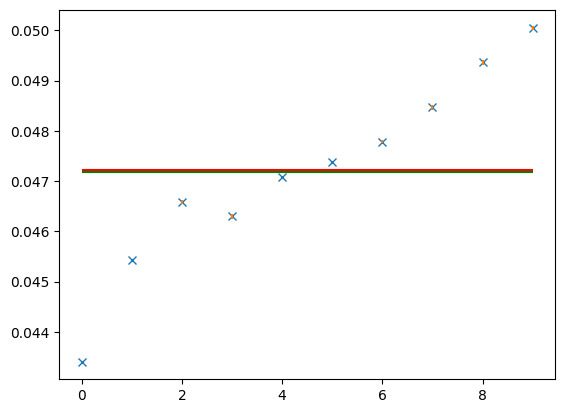

In [157]:
plt.plot(resMean, linestyle='None', marker='x')
plt.errorbar(x,y=resMean, yerr=resStd,linestyle='None')
plt.hlines(resMeanValue,x[0],x[numSwitchEvents-1],color='green', label='Mittelwert')
plt.hlines(resMedianValue,x[0],x[numSwitchEvents-1],color='red', label='Median')
plt.show()

Kommentieren Sie die graphische Darstellung. Was lässt sich über den Kontaktwiderstand und das Messverfahren aussagen?

In [158]:
#Messwerte sind gleichmäßig um den Mittelwert verteilt. Mittelwert und Median liegen nah beieinander, was darauf schließen lässt, dass die relativen Fehler gleich verteilt sind 


Für schnelle und besonders neugierige Studierende: Wiederholen Sie die halbautomatisierte Messung mit dem Kontakt des Reed-Relais. Reduzieren Sie die Strombegrenzung dazu aber auf ca. 20 mA. Wenn das mit dem Einstellknopf am Labornetzteil nicht gelingt, verwenden Sie einen Strombegrenzungswiderstand. 